# Calibration de référence — version pas à pas

Même contenu que `01_calibration_under_pressure.ipynb`, découpé plus finement : une idée par
cellule, des commentaires courts. Les résultats sont les mêmes.

On reproduit la calibration décrite par l'équipe **Under Pressure**, sur le réseau L-Town et son
année de mesures au pas de 5 minutes.

La méthode tient en trois étapes :

1. **décomposer chaque compteur** en un produit d'effets (moyenne, tendance, profil hebdomadaire) ;
2. **transférer** ces formes vers les 700 nœuds qui n'ont aucun compteur ;
3. **ajuster les rugosités** des conduites, par groupes.

> Les mesures doivent être dans `data/raw/`, ou `LTOWN_DIR` doit pointer vers leur dossier.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # pour lancer le carnet depuis notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
DEBUT = 181 * R.PAS_JOUR        # 1er juillet : on ÉVALUE là, c'est la saison la plus exigeante
N_PAS = 7 * R.PAS_JOUR          # fenêtre d'évaluation ; R.PAS_AN pour l'année entière
DEBUT_ENTR = 0                  # 1er janvier : on AJUSTE là, et la raison est plus bas
N_ENTR = 2 * R.PAS_JOUR         # fenêtre d'ajustement (une simulation par évaluation du critère)

R.verifier_donnees(ANNEE)
print(f"évaluation : {N_PAS} pas à partir du pas {DEBUT}")
print(f"ajustement : {N_ENTR} pas à partir du pas {DEBUT_ENTR}")

évaluation : 2016 pas à partir du pas 52128
ajustement : 576 pas à partir du pas 0


Deux fenêtres, et elles ne servent pas à la même chose : on **ajuste** sur l'une, on **évalue**
sur l'autre. Le jeu de données publie les fuites qu'il contient, ce qui permet de dire ce que
chacune porte. On ne s'en sert jamais pour calibrer.

In [2]:
# Les deux fenêtres ne sont pas interchangeables, et le jeu de données permet de dire pourquoi :
# il publie les fuites qu'il contient. On ne s'en sert jamais pour calibrer — uniquement pour
# savoir ce que contient la fenêtre sur laquelle on règle un paramètre.
for nom, d, n in [("ajustement (semaine 1)", DEBUT_ENTR, N_PAS), ("évaluation (juillet)", DEBUT, N_PAS)]:
    c = R.charge_de_fuite(ANNEE, d, n)
    if c:
        print(f"  {nom:24s} fuite {c['debit_m3h']:5.1f} m³/h "
              f"({c['part_conso_ab']:.0%} de la consommation de la grande zone)")

  ajustement (semaine 1)   fuite   0.0 m³/h (0% de la consommation de la grande zone)


  évaluation (juillet)     fuite  12.3 m³/h (7% de la consommation de la grande zone)


## 1. Le réseau et les mesures

In [3]:
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
capteurs = R.capteurs()

zones = R.zones(wn)
bases = R.bases_nominales(wn)
amr = R.charger_amr(ANNEE)

print(f"{len(noeuds)} jonctions, {len(wn.pipe_name_list)} conduites, "
      f"{sum(wn.get_link(p).length for p in wn.pipe_name_list) / 1000:.1f} km")
print(f"capteurs : {len(capteurs['pressure'])} pressions, {len(capteurs['flow'])} débits, "
      f"{len(capteurs['level'])} niveau, {amr.shape[1]} compteurs communicants")

782 jonctions, 905 conduites, 43.2 km
capteurs : 33 pressions, 3 débits, 1 niveau, 82 compteurs communicants


In [4]:
print(f"zones    : {sum(v == 'C' for v in zones.values())} jonctions derrière le réservoir (C), "
      f"{sum(v == 'AB' for v in zones.values())} alimentées directement (A+B)")
print("\ndemande nominale par type de consommateur (m³/h) :")
print(bases.sum().round(2).to_string())

zones    : 92 jonctions derrière le réservoir (C), 690 alimentées directement (A+B)

demande nominale par type de consommateur (m³/h) :
Residential    106.09
Commercial      66.55
Industrial       3.94


In [5]:
# Où sont les compteurs, et où est la demande ?
part_c = bases.sum(axis=1)[[n for n, z in zones.items() if z == "C"]].sum() / bases.sum().sum()
part_amr = bases.sum(axis=1)[amr.columns].sum() / bases.sum().sum()
print(f"la zone C porte {part_c:.1%} de la demande nominale, les nœuds équipés {part_amr:.1%}")
print(f"compteurs situés hors de la zone C : {sum(zones[c] != 'C' for c in amr.columns)}")

la zone C porte 11.1% de la demande nominale, les nœuds équipés 10.0%
compteurs situés hors de la zone C : 0


**Voilà le point qui commande tout le reste.** Les 82 compteurs sont tous dans la même zone,
celle qu'alimente le réservoir, et cette zone ne porte qu'un neuvième de la demande. Les
690 jonctions de la grande zone n'ont aucune mesure de consommation.

Le modèle de demande ne va donc pas interpoler entre des points connus : il va **extrapoler**,
d'une zone vers une autre. C'est une hypothèse forte, à juger sur pièces.

Trois autres éléments de topologie comptent pour la suite :

* deux conduites d'entrée, `p227` et `p235`, amènent toute l'eau, et leur débit est mesuré ;
* une pompe, `PUMP_1`, prélève sur cette arrivée pour remplir le réservoir `T1` ; son débit est
  mesuré aussi ;
* trois réducteurs de pression séparent les sous-zones A et B.

## 2. Le point de départ : le modèle tel qu'il est livré

Le fichier contient déjà, pour chaque jonction, trois demandes de base et trois profils
hebdomadaires. C'est un modèle utilisable tel quel. Mesurons son erreur : c'est la référence que
la calibration doit battre.

In [6]:
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
niveau = R.charger_niveau(ANNEE).to_numpy()
horo = R.horodatage(ANNEE)

In [7]:
D_nominal, _ = P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])
S_nominal = R.pressions_simulees(D_nominal, noeuds, N_PAS, tranche_jours=7,
                                 niveau0=float(niveau[DEBUT]), verbeux=False)

print("modèle livré, sans calibration :")
print(pd.Series(G.resume(S_nominal, mesure)).round(4).to_string())

modèle livré, sans calibration :
biais_m            0.3412
dispersion_m       0.3290
rmse_m             0.4740
max_m              2.2851
n_pas           2016.0000


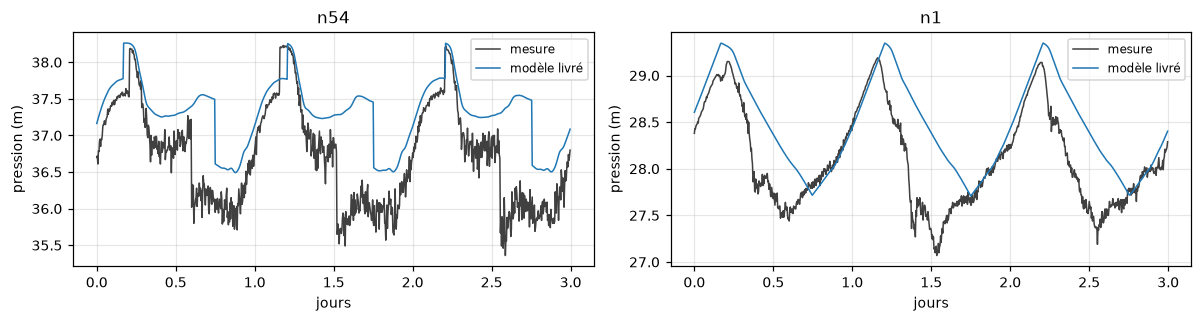

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
G.tracer_capteur(axes[0], S_nominal, mesure, "n54", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
G.tracer_capteur(axes[1], S_nominal, mesure, "n1", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
fig.tight_layout()

### Pourquoi le modèle livré ne peut pas suivre l'année

Ses profils sont **hebdomadaires** : ils se répètent à l'identique du 1er janvier au 31 décembre.
Or la consommation réelle a une saisonnalité annuelle — et on peut la mesurer sans aucun modèle,
par différence entre les débitmètres d'entrée et celui de la pompe.

In [9]:
debits = R.charger_debits(ANNEE)
conso_ab = (debits["p227"] + debits["p235"] - debits["PUMP_1"])   # la mesure directe
print(f"consommation A+B mesurée : {conso_ab.mean():.1f} m³/h en moyenne")

consommation A+B mesurée : 174.9 m³/h en moyenne


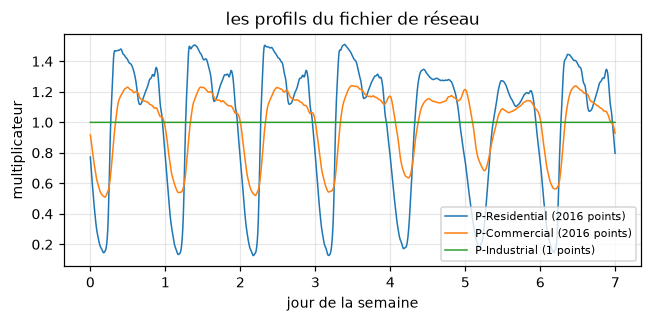

In [10]:
# Les profils du fichier, déroulés sur une semaine.
fig, ax = plt.subplots(figsize=(6, 3.0))
for nom in wn.pattern_name_list:
    m = np.asarray(wn.get_pattern(nom).multipliers)       # P-Industrial ne fait qu'un seul point
    ax.plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR,
            m[np.arange(R.PAS_SEMAINE) % len(m)], lw=1, label=f"{nom} ({len(m)} points)")
ax.set_xlabel("jour de la semaine"); ax.set_ylabel("multiplicateur")
ax.set_title("les profils du fichier de réseau"); ax.legend(fontsize=7)
fig.tight_layout()

amplitude annuelle mesurée : 136.8 à 201.1 m³/h (soit ±18% autour de la moyenne)
amplitude annuelle des profils du fichier : 0 % — ils sont strictement hebdomadaires
à noter : le profil industriel du fichier ne contient qu'un point, il est donc constant


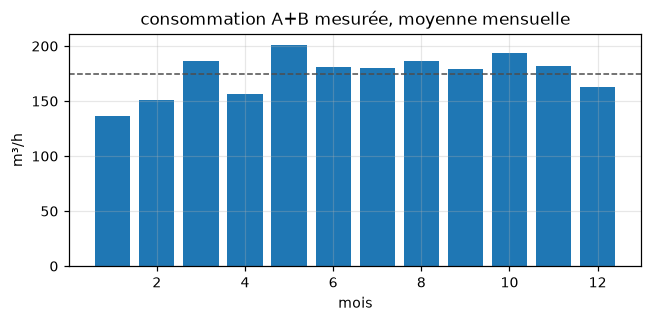

In [11]:
# La consommation réellement mesurée, mois par mois.
mensuel = conso_ab.resample("ME").mean()

fig, ax = plt.subplots(figsize=(6, 3.0))
ax.bar(np.arange(12) + 1, mensuel.to_numpy())
ax.axhline(conso_ab.mean(), color="0.3", ls="--", lw=1)
ax.set_xlabel("mois"); ax.set_ylabel("m³/h")
ax.set_title("consommation A+B mesurée, moyenne mensuelle")
fig.tight_layout()

print(f"amplitude annuelle mesurée : {mensuel.min():.1f} à {mensuel.max():.1f} m³/h "
      f"(soit ±{(mensuel.max() - mensuel.min()) / 2 / mensuel.mean():.0%} autour de la moyenne)")
print("amplitude annuelle des profils du fichier : 0 % — ils sont strictement hebdomadaires")
print("à noter : le profil industriel du fichier ne contient qu'un point, il est donc constant")

Le diagnostic ne demande aucune modélisation : les profils livrés ignorent une variation
saisonnière de plusieurs dizaines de pour cent. C'est exactement le trou que le modèle de demande
vient combler.

## 3. Équation (1) : décomposer un compteur

$$ d(t) = \bar{d} \cdot T(t) \cdot S(t) \cdot R(t) $$

Quatre termes :

* $\bar{d}$ — la moyenne annuelle du compteur ;
* $T(t)$ — la **tendance** : moyenne glissante sur exactement une semaine. Cette largeur annule
  le cycle hebdomadaire, donc ce qui reste est la dérive lente ;
* $S(t)$ — le **profil hebdomadaire** : la moyenne de tous les « mardi 8 h 05 » de l'année
  (52 valeurs), renormalisée à 1 ;
* $R(t)$ — le **résidu**, que la méthode jette.

Jeter le résidu est le choix central. On ne cherche pas à prédire le bruit de consommation d'un
foyer, on cherche la partie **reproductible** — celle qui se transportera vers les nœuds sans
compteur.

(`saisonnalite` propose aussi la médiane, plus robuste ; les deux coïncident sur des compteurs
propres et divergent là où il y a quelque chose à voir.)

In [12]:
compteur = amr.sum().idxmax()          # le compteur le plus chargé, pour la lisibilité
cr = R.creneau(amr.index)
d = P.decomposer(amr[compteur].to_numpy(), cr)

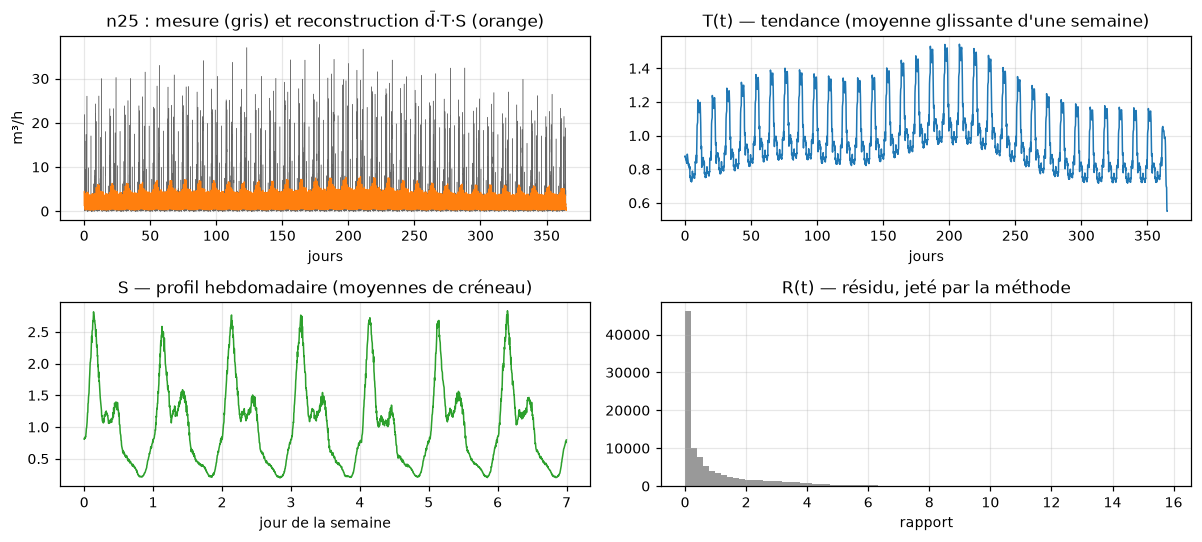

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.0))
j = np.arange(len(amr)) / R.PAS_JOUR

axes[0, 0].plot(j, amr[compteur].to_numpy(), lw=0.3, color="0.4")
axes[0, 0].plot(j, d["lisse"], lw=0.8, color="C1")
axes[0, 0].set_title(f"{compteur} : mesure (gris) et reconstruction d̄·T·S (orange)")
axes[0, 0].set_xlabel("jours"); axes[0, 0].set_ylabel("m³/h")

axes[0, 1].plot(j, d["tendance"], lw=1.0, color="C0")
axes[0, 1].set_title("T(t) — tendance (moyenne glissante d'une semaine)")
axes[0, 1].set_xlabel("jours")

axes[1, 0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, d["saison"], lw=1.0, color="C2")
axes[1, 0].set_title("S — profil hebdomadaire (moyennes de créneau)")
axes[1, 0].set_xlabel("jour de la semaine")

axes[1, 1].hist(d["residu"], bins=80, color="0.6")
axes[1, 1].set_title("R(t) — résidu, jeté par la méthode"); axes[1, 1].set_xlabel("rapport")
fig.tight_layout()

In [14]:
var_expliquee = 1 - np.var(amr[compteur].to_numpy() - d["lisse"]) / np.var(amr[compteur].to_numpy())
print(f"d̄ = {d['moyenne']:.3f} m³/h   |   part de variance portée par d̄·T·S : {var_expliquee:.1%}")

d̄ = 1.835 m³/h   |   part de variance portée par d̄·T·S : 11.1%


À l'échelle d'**un** compteur, le produit $\bar{d}\,T\,S$ n'explique qu'une fraction de la
variance. Une consommation individuelle est largement aléatoire.

Ce n'est pas un échec : c'est la raison d'être de l'étape suivante. Le résidu d'un foyer est
indépendant de celui du voisin, donc en sommant des centaines de nœuds il s'annule — tandis que
la tendance et le profil, eux, s'additionnent. Vérifions-le.

In [15]:
dec = P.decomposer_amr(ANNEE)          # applique l'équation (1) aux 82 compteurs (~15 s)

In [16]:
residu_total = (dec["mesure"].sum(axis=1) - dec["lisse"].sum(axis=1)).to_numpy()
var_tot = 1 - np.var(residu_total) / np.var(dec["mesure"].sum(axis=1).to_numpy())
var_unit = np.mean([1 - np.var(dec["mesure"][c] - dec["lisse"][c]) / np.var(dec["mesure"][c])
                    for c in dec["mesure"].columns])
print(f"variance portée par d̄·T·S, compteur par compteur : {var_unit:.1%}")
print(f"variance portée par d̄·T·S, sur la somme des 82    : {var_tot:.1%}")

variance portée par d̄·T·S, compteur par compteur : 42.1%
variance portée par d̄·T·S, sur la somme des 82    : 71.1%


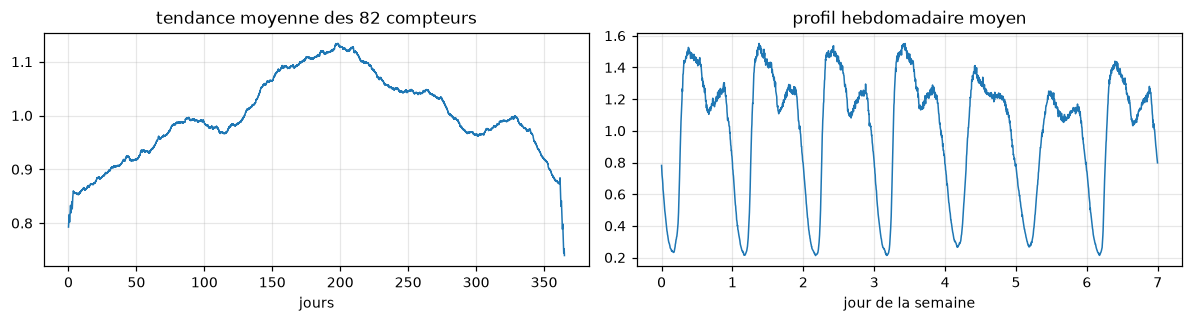

In [17]:
# Les deux formes moyennes des 82 compteurs.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
axes[0].plot(np.arange(len(dec["tendances"])) / R.PAS_JOUR,
             dec["tendances"].mean(axis=1).to_numpy(), lw=1.0)
axes[0].set_title("tendance moyenne des 82 compteurs"); axes[0].set_xlabel("jours")
axes[1].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, dec["saisons"].mean(axis=1).to_numpy(), lw=1.0)
axes[1].set_title("profil hebdomadaire moyen"); axes[1].set_xlabel("jour de la semaine")
fig.tight_layout()

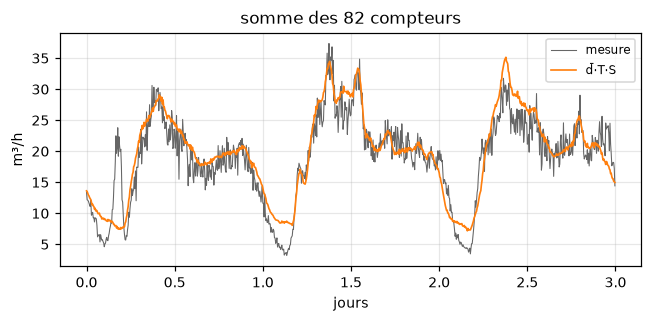

In [18]:
# Un compteur seul contre la somme des 82 : c'est toute la thèse de la section.
jours = slice(DEBUT, DEBUT + 3 * R.PAS_JOUR)
t3 = np.arange(3 * R.PAS_JOUR) / R.PAS_JOUR

fig, ax = plt.subplots(figsize=(6, 3.0))
ax.plot(t3, dec["mesure"].sum(axis=1).to_numpy()[jours], lw=0.7, color="0.4", label="mesure")
ax.plot(t3, dec["lisse"].sum(axis=1).to_numpy()[jours], lw=1.1, color="C1", label="d̄·T·S")
ax.set_title("somme des 82 compteurs"); ax.set_xlabel("jours")
ax.set_ylabel("m³/h"); ax.legend(fontsize=8)
fig.tight_layout()

In [19]:
un = dec["mesure"][compteur].to_numpy()
somme = dec["mesure"].sum(axis=1).to_numpy()
print(f"amplitude restituée sur {compteur} seul   : "
      f"{dec['lisse'][compteur].std() / un.std():.0%} de l'écart-type mesuré")
print(f"amplitude restituée sur la somme des 82 : "
      f"{dec['lisse'].sum(axis=1).std() / somme.std():.0%}")
print(f"\n{compteur} : médiane {np.median(un):.2f} m³/h, maximum {un.max():.2f}, "
      f"nul {np.mean(un == 0):.0%} du temps — une consommation individuelle est faite de pointes")

amplitude restituée sur n25 seul   : 34% de l'écart-type mesuré
amplitude restituée sur la somme des 82 : 85%

n25 : médiane 0.35 m³/h, maximum 37.80, nul 10% du temps — une consommation individuelle est faite de pointes


### Lecture

Sur **un** compteur, la reconstruction ne restitue qu'un tiers de l'amplitude ; sur la **somme**
des 82, elle en restitue l'essentiel. C'est le même calcul, appliqué au même signal : seule
l'échelle change.

Et c'est bien l'échelle qui compte, puisqu'on va s'en servir pour alimenter des nœuds, pas pour
prédire un foyer.

## 4. Équation (2) : des compteurs vers les nœuds sans mesure

$$ \hat{d}_i(t) = \sum_j \bar{d}_{ij} \cdot T_j(t) \cdot S_j(t) $$

**Attention à la lecture : c'est une somme, pas un produit.**

Le produit de l'équation (1) porte sur les effets temporels d'un même compteur. La somme ici
répartit un **nœud** entre plusieurs **types** de consommateurs (résidentiel, commercial,
industriel).

Les poids $\bar{d}_{ij}$ sont donnés : le fichier attribue à chaque jonction trois demandes de
base, une par type. Ce sont les formes $T_j\!\cdot\!S_j$ qu'il faut estimer.

On les obtient en résolvant la même équation **à l'envers**, là où la mesure existe : avec $W$ la
matrice 82 × 3 des demandes nominales des nœuds équipés et $A$ les séries lissées, on résout
$W\,m(t) = A(t)$ aux moindres carrés, à chaque pas.

In [20]:
# Comment le fichier répartit la demande entre les trois types de consommateurs.
bases = R.bases_nominales(wn)
zone = pd.Series(R.zones(wn))
n_types = (bases > 0).sum(axis=1)

print("nombre de types de consommateurs par jonction :")
print(pd.crosstab(zone, n_types, rownames=["zone"], colnames=["types portés"]).to_string())
print("\ndemande nominale par zone et par type (m³/h) :")
print(bases.groupby(zone).sum().round(2).to_string())
print(f"\nnœuds portant de l'industriel : {list(bases[bases.Industrial > 0].index)}")
print(f"  tous en zone C et tous équipés d'un compteur : "
      f"{all(zone[n] == 'C' and n in amr.columns for n in bases[bases.Industrial > 0].index)}")

nombre de types de consommateurs par jonction :
types portés   0    1    2
zone                      
AB            35  102  553
C              0   84    8

demande nominale par zone et par type (m³/h) :
    Residential  Commercial  Industrial
AB        92.23       64.76        0.00
C         13.85        1.79        3.94

nœuds portant de l'industriel : ['n1', 'n4', 'n25', 'n347']
  tous en zone C et tous équipés d'un compteur : True


Trois choses à retenir de ce tableau, et elles changent la lecture de l'équation (2).

**Aucune jonction ne porte les trois types.** 186 n'en portent qu'un, 561 en portent exactement
deux — toujours résidentiel + commercial — et 35 n'ont aucune demande. La somme de l'équation (2)
n'a donc jamais plus de deux termes.

**La demande industrielle vaut exactement zéro dans la zone A+B.** Elle n'existe que sur quatre
nœuds, tous en zone C, et tous équipés d'un compteur.

**Donc la forme industrielle n'est jamais extrapolée.** C'est la plus bruitée des trois — on la
verra plus bas, estimée sur quatre compteurs — mais elle ne sert qu'à des nœuds dont on mesure
déjà la consommation. Le risque se limite à ce qu'elle absorbe du bruit au détriment des deux
autres lors de l'inversion, ce que le conditionnement de $W$ permet de contrôler.

In [21]:
formes = P.formes_par_categorie(wn, ANNEE, dec)

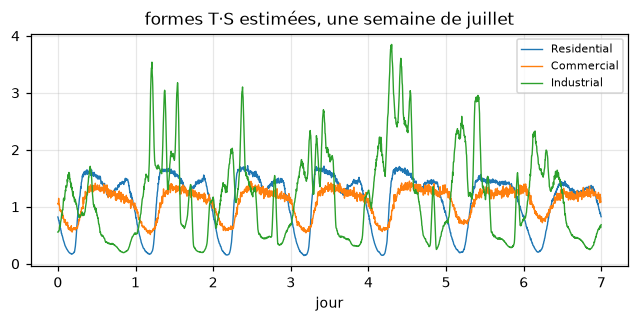

In [22]:
# Les trois formes, sur une semaine de juillet.
fig, ax = plt.subplots(figsize=(6, 3.0))
sem = slice(DEBUT, DEBUT + R.PAS_SEMAINE)
for c in formes.columns:
    ax.plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, formes[c].to_numpy()[sem], lw=0.9, label=c)
ax.set_title("formes T·S estimées, une semaine de juillet")
ax.set_xlabel("jour"); ax.legend(fontsize=7)
fig.tight_layout()

rapport max/min sur l'année :
Residential    1.30
Commercial     1.32
Industrial     1.36


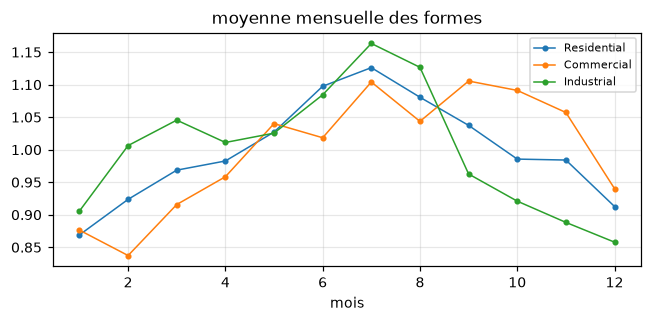

In [23]:
# Les mêmes, moyennées par mois : c'est là que se voit la saisonnalité.
mens = formes.resample("ME").mean()

fig, ax = plt.subplots(figsize=(6, 3.0))
for c in formes.columns:
    ax.plot(np.arange(12) + 1, mens[c].to_numpy(), marker="o", ms=3, lw=1, label=c)
ax.set_title("moyenne mensuelle des formes"); ax.set_xlabel("mois"); ax.legend(fontsize=7)
fig.tight_layout()

print("rapport max/min sur l'année :")
print((mens.max() / mens.min()).round(2).to_string())

### Lecture

Les trois formes ont une saisonnalité **d'amplitude comparable** — un rapport max/min de 1,30 à
1,36 — que le modèle livré n'avait pas du tout.

Ce qui les distingue n'est pas l'amplitude mais la **phase** : le résidentiel culmine en juillet,
le commercial en septembre. Deux mois d'écart, et c'est là l'information.

**Première réserve : le profil industriel n'est pas un résultat.**

Il est estimé sur **4 nœuds équipés** seulement — contre 75 pour le résidentiel et 10 pour le
commercial — et c'est pourtant la forme la plus agitée des trois. Ce n'est pas un signal
industriel, c'est le bruit de quatre compteurs.

Ce qui limite les dégâts est plus fort qu'une question de poids : ces quatre nœuds sont **les
seuls** du réseau à porter de l'industriel, ils sont tous en zone C, et ils sont tous équipés. La
forme industrielle n'est donc jamais transportée vers un nœud non mesuré.

**Seconde réserve : ces formes sont estimées sur une zone et appliquées à une autre.**

82 compteurs de la zone C, 690 jonctions dans A+B. Rien dans les données ne garantit que les
habitudes de consommation y soient les mêmes.

In [24]:
D_calibre, noeuds_c = P.demandes_calibrees(wn, ANNEE, formes)
assert noeuds_c == noeuds

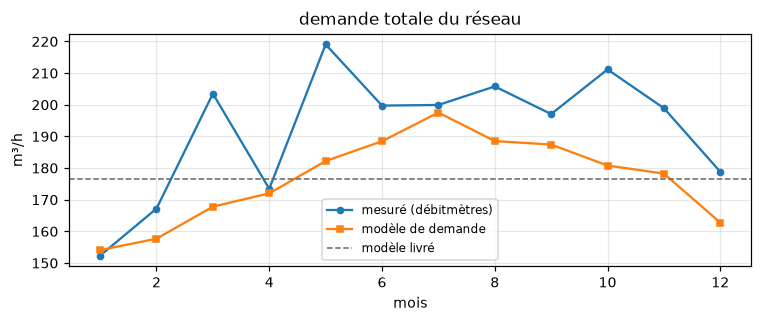

In [25]:
# Contrôle indépendant : la demande totale du modèle contre le bilan de masse des débitmètres
total_modele = pd.Series(D_calibre.sum(axis=1), index=horo).resample("ME").mean()
total_nominal = P.demandes_nominales(wn, horo[:R.PAS_SEMAINE])[0].sum(axis=1).mean()
total_mesure = (conso_ab + R.charger_amr(ANNEE).sum(axis=1)).resample("ME").mean()

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(np.arange(12) + 1, total_mesure.to_numpy(), marker="o", ms=4, label="mesuré (débitmètres)")
ax.plot(np.arange(12) + 1, total_modele.to_numpy(), marker="s", ms=4, label="modèle de demande")
ax.axhline(total_nominal, color="0.4", ls="--", lw=1, label="modèle livré")
ax.set_xlabel("mois"); ax.set_ylabel("m³/h"); ax.set_title("demande totale du réseau")
ax.legend(fontsize=8)
fig.tight_layout()

La forme saisonnière est retrouvée, et il reste un **écart de niveau** : le modèle de demande est
systématiquement en dessous de ce que les débitmètres mesurent.

Cet écart n'est pas un défaut du modèle. Le bilan de masse `p227 + p235 − PUMP_1` mesure tout ce
qui **sort** vers la zone A+B, ce qui inclut ce qui y fuit ; le modèle de demande, lui, ne
reconstruit que ce qui est **consommé**. Le carnet 4 fait la soustraction avec les fuites publiées
par le jeu de données : le modèle tombe alors à **+0,2 %** de la consommation réelle de A+B sur
l'année, et l'intégralité de l'écart au bilan brut est de la fuite.

C'est à retenir pour le second carnet, qui recale la demande sur ce bilan **brut** : le recalage
améliore les pressions parce que cette eau circule réellement, mais il inscrit la fuite dans la
demande.

## 5. Ce que le modèle de demande change sur les pressions

In [26]:
S_demande = R.pressions_simulees(D_calibre[DEBUT:DEBUT + N_PAS + 1], noeuds, N_PAS,
                                 tranche_jours=7, niveau0=float(niveau[DEBUT]), verbeux=False)

variantes = {"modèle livré": S_nominal, "modèle de demande": S_demande}
print(G.tableau(variantes, mesure).round(4).to_string())

                   biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle livré        0.3412        0.3290  0.4740  2.2851  2016.0           0.0000     0.0000
modèle de demande   0.2022        0.2526  0.3235  1.7974  2016.0          -0.2324    -0.3174


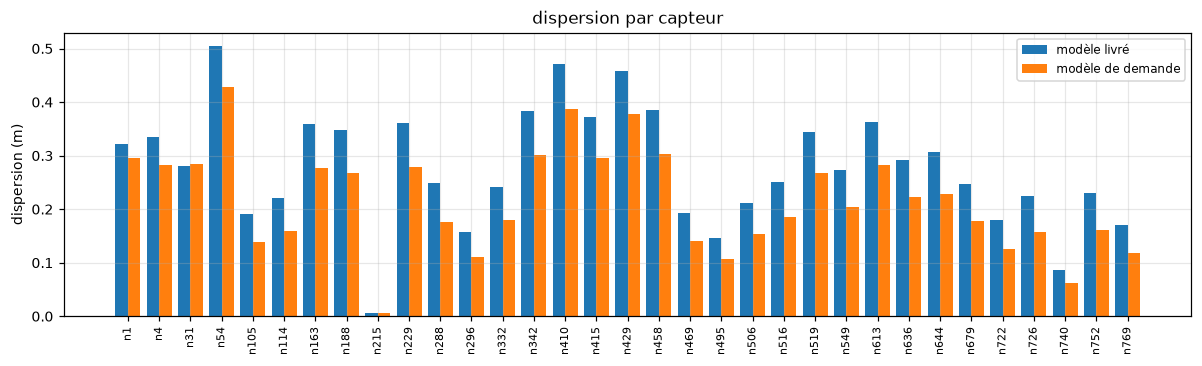

In [27]:
fig, ax = plt.subplots(figsize=(11, 3.4))
G.tracer_par_capteur(ax, {k: G.par_capteur(v, mesure) for k, v in variantes.items()},
                     "dispersion_m")
ax.set_title("dispersion par capteur")
fig.tight_layout()

## 6. Les rugosités : six groupes et moindres carrés sous contraintes

Les 905 conduites n'entrent dans les équations que par leur résistance

$$ R = \frac{10{,}674\,L}{C^{1,852} D^{4,871}} $$

et l'on ne dispose que de 33 capteurs. Les calibrer une par une n'aurait aucun sens : la méthode
les **regroupe** — même matériau, âge, diamètre — et n'ajuste qu'un coefficient par groupe. Six
groupes, formés ici par classe de diamètre.

Le critère n'est pas une simple somme de carrés. C'est un moindres carrés pondéré **sous
contraintes de boîte**, avec perte de **Huber** contre les pas aberrants et **régularisation de
Tikhonov** vers la valeur du fichier :

$$ \min_{x_L \le x \le x_U} \ \tfrac12 \sum_j \sum_i H_\kappa\!\left(\frac{[S\,y(t_j,x)]_i - z^j_i}{\sigma_{ij}}\right) + \alpha \lVert x - x_0 \rVert^2 $$

`rugosite.ajuster` implémente les trois garde-fous, mais **deux seulement sont actifs ici** : les
bornes (60 à 160, l'encadrement de la référence) et la perte de Huber. Le coefficient $\alpha$
vaut zéro par défaut et ce carnet ne le change pas — il reproduit la référence à ce détail près.

Le solveur n'est pas Levenberg-Marquardt au sens strict mais une région de confiance
réfléchissante : LM n'accepte pas de bornes, or le critère en pose.

**Sur quelle fenêtre ajuster ?** Sur la première semaine de l'année (`DEBUT_ENTR = 0`), comme la
référence — alors qu'on *évalue* en juillet. C'est la seule semaine qui ne porte aucune fuite.

Le second carnet montre que ce choix compte moins qu'on ne pourrait le croire, mais qu'il compte
quand même : il y mesure ce que ces six coefficients apprennent vraiment.

In [28]:
groupes = R.groupes_de_rugosite(wn, n_groupes=6)
noms_groupes = sorted(set(groupes.values()))
depart = U.coefficients_initiaux(wn, groupes)
print(pd.Series(groupes).value_counts().to_string())

D100     705
D150     103
D200      64
D160      16
D225      12
D<=75      5


In [29]:
mesure_entr = R.charger_pressions(ANNEE).to_numpy()[DEBUT_ENTR:DEBUT_ENTR + N_ENTR]

def simulateur(coefficients):
    # une évaluation = une simulation complète de la fenêtre d'ajustement
    return R.pressions_simulees(D_calibre[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1], noeuds, N_ENTR,
                                tranche_jours=7, niveau0=float(niveau[DEBUT_ENTR]), verbeux=False,
                                coefficients=U.coefficients_par_conduite(groupes, coefficients))

In [30]:
# attention au coût : chaque colonne du jacobien demande une simulation de plus, si bien que le
# nombre de simulations réellement lancées dépasse largement `max_nfev`
ajustement = U.ajuster(simulateur, mesure_entr, depart, max_nfev=12, verbeux=False)
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s")
print(f"RMSE sur la fenêtre d'ajustement : {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print("\ncoefficients de Hazen-Williams retenus :")
print(pd.Series(ajustement["coefficients"]).round(1).to_string())
print(f"\ndépart : {pd.Series(ajustement['depart']).round(1).to_dict()}")
print(f"groupes arrêtés sur une borne : {ajustement['aux_bornes'] or 'aucun'}")

55 simulations en 53 s
RMSE sur la fenêtre d'ajustement : 0.2455 → 0.2099 m

coefficients de Hazen-Williams retenus :
D100     112.1
D150     137.1
D160     158.3
D200     124.8
D225      70.0
D<=75    157.6

départ : {'D100': 137.1, 'D150': 137.7, 'D160': 140.0, 'D200': 140.0, 'D225': 140.0, 'D<=75': 135.3}
groupes arrêtés sur une borne : aucun


**Aucun groupe ne s'arrête sur une borne**, et les coefficients restent dans une plage plausible.
C'est le signe minimal qu'on attend d'un ajustement — pas encore la preuve qu'il a appris quelque
chose. Regardons ce qu'il change sur la fenêtre d'évaluation.

In [31]:
S_rugosite = R.pressions_simulees(
    D_calibre[DEBUT:DEBUT + N_PAS + 1], noeuds, N_PAS, tranche_jours=7,
    niveau0=float(niveau[DEBUT]), verbeux=False,
    coefficients=U.coefficients_par_conduite(groupes, ajustement["coefficients"]))

variantes["+ rugosités ajustées"] = S_rugosite
print(G.tableau(variantes, mesure).round(4).to_string())

                      biais_m  dispersion_m  rmse_m   max_m   n_pas  gain_dispersion  gain_rmse
modèle livré           0.3412        0.3290  0.4740  2.2851  2016.0           0.0000     0.0000
modèle de demande      0.2022        0.2526  0.3235  1.7974  2016.0          -0.2324    -0.3174
+ rugosités ajustées   0.0195        0.2584  0.2591  1.6679  2016.0          -0.2146    -0.4532


## 7. Bilan

Reprenons les trois variantes sur deux saisons, pour ne pas conclure sur une semaine
particulière.

In [32]:
def evaluer(debut, n=3 * R.PAS_JOUR):
    mes = R.charger_pressions(ANNEE).to_numpy()[debut:debut + n]
    Dn, _ = P.demandes_nominales(wn, horo[debut:debut + n + 1])
    faire = lambda D, **kw: R.pressions_simulees(D, noeuds, n, tranche_jours=7,
                                                 niveau0=float(niveau[debut]), verbeux=False, **kw)
    v = {"modèle livré": faire(Dn),
         "modèle de demande": faire(D_calibre[debut:debut + n + 1]),
         "+ rugosités ajustées": faire(
             D_calibre[debut:debut + n + 1],
             coefficients=U.coefficients_par_conduite(groupes, ajustement["coefficients"]))}
    return G.tableau(v, mes)

bilan = pd.concat({"janvier": evaluer(3 * R.PAS_JOUR), "juillet": evaluer(DEBUT)})
print(bilan[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion"]].round(4).to_string())

                              biais_m  dispersion_m  rmse_m  gain_dispersion
janvier modèle livré          -0.1428        0.2162  0.2591           0.0000
        modèle de demande      0.0536        0.1229  0.1341          -0.4318
        + rugosités ajustées  -0.0541        0.1144  0.1265          -0.4709
juillet modèle livré           0.3320        0.3090  0.4535           0.0000
        modèle de demande      0.2050        0.2289  0.3072          -0.2594
        + rugosités ajustées   0.0196        0.2140  0.2149          -0.3075


### Ce qu'il faut retenir

1. **Le modèle de demande apporte la saisonnalité annuelle**, qui manquait complètement. Le gain
   sur la dispersion est net dans les deux saisons, et plus fort en hiver qu'en été.
2. **Il reste un biais important en été.** L'extrapolation d'une zone à l'autre retrouve la
   *forme* de la demande mieux que son *niveau* — et le niveau, lui, se mesure directement aux
   débitmètres. Le second carnet s'en sert.
3. **L'ajustement des rugosités agit sur le biais, pas sur la dynamique.** Il ramène le décalage
   de +0,20 m à +0,02 m tandis que la dispersion ne bouge quasiment pas. La RMSE s'améliore donc
   beaucoup, et le modèle guère.

Et un constat de méthode, qui commande la suite : **une part importante de l'erreur restante est
un biais, et un biais ne dit rien de la dynamique.** Le second carnet s'attaque à ce qui reste —
en regardant non pas ce que le modèle de demande pourrait faire de mieux, mais ce que les
capteurs disent déjà et que le modèle n'écoute pas.